# 03 — Fine-Tuning: Experimentos A y B

**Proyecto:** Clasificación de Residuos — Economía Circular  
**Fase:** 4 — Fine-Tuning  
**Punto de partida:** `baseline_e96de0c723f2_best.keras` (val_accuracy: 92.98%, overfitting: 3.16%)  

---

## ¿Qué es el fine-tuning y por qué lo hacemos?

En el baseline entrenamos **solo la cabeza clasificadora** (los ~235K parámetros añadidos encima de EfficientNetB0).  
El backbone —los 4M parámetros de EfficientNetB0— estaba **congelado**, extrayendo features genéricas aprendidas en ImageNet.

El fine-tuning **descongela las capas superiores del backbone** para que se especialicen en nuestro dominio específico (residuos).  
Las capas superiores de una CNN aprenden features de alto nivel: texturas, formas complejas, patrones de superficie.  
Son exactamente las que necesitamos para resolver las confusiones detectadas:

| Confusión | % error | Por qué el fine-tuning ayuda |
|-----------|---------|-----------------------------|
| cartón ↔ papel | ~6.9% / 6.0% | Texturas distintas (rugoso vs liso) — features de nivel alto |
| metal ↔ plástico | ~6.0% | Brillos similares — el modelo necesita aprender reflejos específicos |
| vidrio ↔ plástico | ~2.5% | Transparencia — frontera visual fina |

## Estrategia de 2 experimentos

```
Experimento A → Descongelar últimas 30 capas | LR=1e-5 | 15 epochs
                         ↓
              ¿Mejora sobre 92.98% con overfitting <5%?
                    SÍ ↓              NO → Cerrar fase con baseline
Experimento B → Descongelar últimas 50 capas | LR=5e-6 | 15 epochs
```

**¿Por qué LR tan bajo (1e-5)?**  
Los pesos preentrenados de ImageNet son frágiles. Un LR alto los destruye en pocas iteraciones.  
Regla práctica: LR del fine-tuning = LR_baseline / 100 como mínimo.

**¿Por qué partir del checkpoint y no desde cero?**  
El checkpoint ya tiene 20 epochs de aprendizaje específico del dominio residuos.  
Empezar desde ImageNet puro requeriría ~20 epochs adicionales para recuperar ese conocimiento.

---

## Bloque 0 — Imports y configuración del entorno

**Propósito:** Cargar todas las dependencias, detectar el entorno (WSL/Colab) y configurar las rutas.  
**Resultado esperado:** GPU detectada, rutas resueltas, sin errores de import.  

> **Defensa:** Centralizar la configuración aquí permite cambiar rutas en un solo lugar si se mueve a Colab.

In [5]:
import os
import sys
import json
import hashlib
import shutil
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# ── Reproducibilidad ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── Detección de entorno ──────────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/waste_classifier')
    print("Entorno: Google Colab — Drive montado")
else:
    BASE_DIR = Path('../../').resolve()   # raíz del proyecto desde notebooks/
    print("Entorno: Local (WSL)")

# ── Rutas del proyecto ────────────────────────────────────────────────────────
PATHS = {
    'data_raw'    : BASE_DIR / 'data' / 'raw',
    'splits'      : BASE_DIR / 'data' / 'splits',
    'models'      : BASE_DIR / 'models',
    'logs'        : BASE_DIR / 'logs',
    'src'         : BASE_DIR / 'src',
}

# ── Baseline a cargar ─────────────────────────────────────────────────────────
BASELINE_MODEL_PATH = PATHS['models'] / 'baseline_e96de0c723f2_best.keras'

# ── Clases del modelo (mismo orden que el baseline) ──────────────────────────
# ── Clases del modelo — ORDEN EXACTO de data_pipeline.py ─────────────────────
# CRÍTICO: este orden debe coincidir con CLASS_TO_IDX de data_pipeline.py
# Si cambia el orden, la matriz de confusión mapea etiquetas incorrectas
from data_pipeline import CLASSES, CLASS_TO_IDX, IDX_TO_CLASS
WASTE_CLASSES = CLASSES   # ['vidrio', 'plastico', 'metal', 'papel', 'organico', 'carton', 'no_reciclable']
NUM_CLASSES   = len(WASTE_CLASSES)

print(f"Clases ({NUM_CLASSES}): {WASTE_CLASSES}")
print(f"Mapeo índice→clase: {IDX_TO_CLASS}")

# ── Verificaciones ────────────────────────────────────────────────────────────
assert BASELINE_MODEL_PATH.exists(), f"No se encuentra el baseline: {BASELINE_MODEL_PATH}"
assert PATHS['splits'].exists(),     f"No se encuentran los splits: {PATHS['splits']}"

print(f"\nGPU disponible: {tf.config.list_physical_devices('GPU')}")
print(f"TensorFlow: {tf.__version__}")
print(f"Baseline cargable desde: {BASELINE_MODEL_PATH}")
print(f"Clases ({NUM_CLASSES}): {WASTE_CLASSES}")

Entorno: Local (WSL)
Clases (7): ['vidrio', 'plastico', 'metal', 'papel', 'organico', 'carton', 'no_reciclable']
Mapeo índice→clase: {0: 'vidrio', 1: 'plastico', 2: 'metal', 3: 'papel', 4: 'organico', 5: 'carton', 6: 'no_reciclable'}

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.20.0
Baseline cargable desde: /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/baseline_e96de0c723f2_best.keras
Clases (7): ['vidrio', 'plastico', 'metal', 'papel', 'organico', 'carton', 'no_reciclable']


## Bloque 1 — Cargar baseline y verificar estado de congelación

**Propósito:** Cargar el modelo entrenado, inspeccionar su arquitectura y confirmar qué capas están congeladas.  
**Resultado esperado:** Modelo cargado con 92.98% de accuracy en validación. Visualización de las capas y su estado.  

> **Por qué inspeccionar antes de descongelar:**  
> Necesitamos conocer el índice exacto de las capas para descongelar precisamente las últimas 30 o 50.  
> Descongelar capas incorrectas (ej. BatchNormalization en capas tempranas) puede desestabilizar el entrenamiento.

In [6]:
# Añadir src/ al path para importar data_pipeline
sys.path.insert(0, str(PATHS['src']))
from data_pipeline import build_dataset, get_class_weights

# ── Cargar el modelo baseline completo ───────────────────────────────────────
# Cargamos el modelo entero (.keras incluye arquitectura + pesos + config optimizer)
# Esto preserva todo lo aprendido en los 20 epochs del baseline
baseline_model = keras.models.load_model(BASELINE_MODEL_PATH)

print(f"Modelo cargado: {BASELINE_MODEL_PATH.name}")
print(f"Total parámetros: {baseline_model.count_params():,}")

# ── Localizar el backbone EfficientNetB0 dentro del modelo ───────────────────
# El modelo tiene estructura: inputs → EfficientNetB0 → cabeza clasificadora
# Necesitamos el índice del backbone para congelar/descongelar con precisión
backbone = None
for layer in baseline_model.layers:
    if 'efficientnet' in layer.name.lower():
        backbone = layer
        break

assert backbone is not None, "No se encontró EfficientNetB0 en el modelo"
print(f"\nBackbone encontrado: {backbone.name}")
print(f"Capas en el backbone: {len(backbone.layers)}")

# ── Inspeccionar estado actual de congelación ─────────────────────────────────
# Contar cuántas capas están entrenables vs congeladas actualmente
trainable_now    = sum(1 for l in backbone.layers if l.trainable)
non_trainable_now = sum(1 for l in backbone.layers if not l.trainable)

print(f"\nEstado actual del backbone:")
print(f"  Capas entrenables  : {trainable_now}")
print(f"  Capas congeladas   : {non_trainable_now}")

# ── Mostrar las últimas 35 capas del backbone (las que descongelaremos) ───────
print(f"\nÚltimas 35 capas del backbone (candidatas a descongelar):")
print(f"{'Idx':>5}  {'Nombre':<55}  {'Entrena':<10}  {'Tipo'}")
print("-" * 90)
for i, layer in enumerate(backbone.layers[-35:]):
    real_idx = len(backbone.layers) - 35 + i
    print(f"{real_idx:>5}  {layer.name:<55}  {str(layer.trainable):<10}  {layer.__class__.__name__}")

Modelo cargado: baseline_e96de0c723f2_best.keras
Total parámetros: 4,384,426

Backbone encontrado: efficientnetb0
Capas en el backbone: 238

Estado actual del backbone:
  Capas entrenables  : 1
  Capas congeladas   : 237

Últimas 35 capas del backbone (candidatas a descongelar):
  Idx  Nombre                                                   Entrena     Tipo
------------------------------------------------------------------------------------------
  203  block6c_project_conv                                     False       Conv2D
  204  block6c_project_bn                                       False       BatchNormalization
  205  block6c_drop                                             False       Dropout
  206  block6c_add                                              False       Add
  207  block6d_expand_conv                                      False       Conv2D
  208  block6d_expand_bn                                        False       BatchNormalization
  209  block6d_expand_activa

## Bloque 2 — Datasets de entrenamiento y validación

**Propósito:** Cargar los splits ya generados (train.csv / val.csv) usando el mismo `data_pipeline.py` del baseline.  
**Resultado esperado:** Dos `tf.data.Dataset` listos, con los mismos hiperparámetros de preprocesado que el baseline.  

> **Importante:** Usar exactamente el mismo pipeline de datos garantiza que las mejoras vienen del fine-tuning,  
> no de cambios accidentales en el preprocesado. La comparación con el baseline sería inválida de otra forma.

In [7]:
# ── Cargar class weights del EDA ──────────────────────────────────────────────
class_weights = get_class_weights(PATHS['logs'] / 'class_weights.json')
print(f"\nClass weights: {class_weights}")

# ── Parámetros del dataset ────────────────────────────────────────────────────
BATCH_SIZE = 32

# ── Construir datasets ────────────────────────────────────────────────────────
# FIRMA REAL: build_dataset(csv_path, split, batch_size=32, augment=None)
# split controla: shuffle interno (solo train) y si aplica augmentation
# augment='global' → capa moderada para todo el dataset
# augment=None     → sin augmentation (val y test SIEMPRE sin augmentation)

train_ds = build_dataset(
    csv_path   = PATHS['splits'] / 'train.csv',
    split      = 'train',
    batch_size = BATCH_SIZE,
    augment    = 'global',   # augmentation solo en train
)

val_ds = build_dataset(
    csv_path   = PATHS['splits'] / 'val.csv',
    split      = 'val',
    batch_size = BATCH_SIZE,
    augment    = None,       # NUNCA augmentation en validación
)

# ── Verificación del rango de valores ─────────────────────────────────────────
# El rango esperado es [0, 255] — EfficientNetB0 normaliza internamente
# Si ves [-1, 1] aquí → hay doble normalización (el error WSL v2)
for images, labels in train_ds.take(1):
    print(f"\nBatch shape   : {images.shape}")
    print(f"Dtype         : {images.dtype}")
    print(f"Rango valores : [{images.numpy().min():.1f}, {images.numpy().max():.1f}]")
    print(f"Labels shape  : {labels.shape}")
    print(f"Labels ejemplo: {labels.numpy()[:5]} → {[IDX_TO_CLASS[i] for i in labels.numpy()[:5]]}")

[get_class_weights] Pesos cargados:
  0 · vidrio          → 0.6386
  1 · plastico        → 0.8722
  2 · metal           → 1.0018
  3 · papel           → 1.0065
  4 · organico        → 1.1177
  5 · carton          → 1.1543
  6 · no_reciclable   → 1.8699

Class weights: {0: 0.6386, 1: 0.8722, 2: 1.0018, 3: 1.0065, 4: 1.1177, 5: 1.1543, 6: 1.8699}
[build_dataset] split='train' | 7644 imágenes | batch_size=32 | augment=global
[build_dataset] split='val' | 1639 imágenes | batch_size=32 | augment=None

Batch shape   : (32, 224, 224, 3)
Dtype         : <dtype: 'float32'>
Rango valores : [0.0, 255.0]
Labels shape  : (32,)
Labels ejemplo: [3 2 5 0 1] → ['papel', 'metal', 'carton', 'vidrio', 'plastico']


2026-03-19 14:36:01.490732: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Bloque 3 — Experimento A: Fine-tuning superficial (últimas 30 capas)

**Propósito:** Descongelar las últimas 30 capas del backbone y reentrenar con LR muy bajo.  
**Resultado esperado:** Val accuracy > 92.98% con overfitting < 5%.  

### ¿Por qué las últimas 30 capas?

En EfficientNetB0 con ~237 capas totales en el backbone, las últimas 30 corresponden aproximadamente al **bloque MBConv7 + top_conv**.  
Son las capas que aprenden las representaciones de más alto nivel — las más específicas del dominio.  
Las primeras capas (bordes, colores básicos) son universales y no necesitan cambiar.

### ¿Por qué LR = 1e-5?

El LR del baseline fue `1e-3`. El fine-tuning usa `1e-5` (100 veces menor) porque:  
- Los pesos preentrenados ya son buenos — queremos ajustarlos, no destruirlos  
- Un LR alto produce **catastrophic forgetting**: el modelo olvida todo lo aprendido

### Nota sobre BatchNormalization en fine-tuning

Las capas `BatchNormalization` del backbone se mantienen en **modo inferencia** (`training=False`).  
Si se ponen en modo entrenamiento con pocas muestras, las estadísticas de batch se corrompen.  
Esto se controla fijando `layer.trainable = True` solo en capas que NO sean BatchNorm.

In [8]:
# ── Identificador único del experimento ──────────────────────────────────────
EXP_A_ID = f"finetune_A_{hashlib.md5(b'exp_A_30layers').hexdigest()[:8]}"
EXP_A_LOG_DIR = PATHS['logs'] / EXP_A_ID
EXP_A_LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento A ID: {EXP_A_ID}")

# ── Parámetros del Experimento A ─────────────────────────────────────────────
EXP_A_CONFIG = {
    'layers_to_unfreeze' : 30,
    'learning_rate'      : 1e-5,
    'epochs'             : 15,
    'early_stopping_patience': 4,
    'reduce_lr_patience' : 2,
    'reduce_lr_factor'   : 0.3,
}

# ── Crear copia del baseline para no modificar el original ───────────────────
# Trabajamos sobre una copia — el baseline queda intacto para comparar
model_A = keras.models.load_model(BASELINE_MODEL_PATH)

# ── Localizar el backbone en el nuevo modelo ─────────────────────────────────
backbone_A = None
for layer in model_A.layers:
    if 'efficientnet' in layer.name.lower():
        backbone_A = layer
        break

# ── Paso 1: Congelar TODO el backbone ─────────────────────────────────────────
backbone_A.trainable = False
print(f"Backbone congelado completamente.")

# ── Paso 2: Descongelar las últimas N capas (excepto BatchNorm) ───────────────
# Descongelamos las últimas 30 capas del backbone
# Las BatchNormalization siempre se dejan en modo inferencia durante fine-tuning
N = EXP_A_CONFIG['layers_to_unfreeze']
layers_to_unfreeze = backbone_A.layers[-N:]

unfrozen_count = 0
for layer in layers_to_unfreeze:
    if not isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = True
        unfrozen_count += 1

# ── Verificar resultado ───────────────────────────────────────────────────────
total_trainable   = sum(l.count_params() for l in model_A.layers if l.trainable)
total_params      = model_A.count_params()
trainable_backbone = sum(1 for l in backbone_A.layers if l.trainable)

print(f"\nEstado Experimento A:")
print(f"  Capas del backbone descongeladas : {trainable_backbone} ({unfrozen_count} non-BN)")
print(f"  Parámetros entrenables           : {total_trainable:,} / {total_params:,}")
print(f"  % del modelo entrenable          : {100*total_trainable/total_params:.1f}%")

# ── Compilar con LR muy bajo ──────────────────────────────────────────────────
# CRÍTICO: recompilar después de cambiar trainable — de lo contrario los cambios no se aplican
model_A.compile(
    optimizer = keras.optimizers.Adam(learning_rate=EXP_A_CONFIG['learning_rate']),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

print(f"\nModelo compilado con LR={EXP_A_CONFIG['learning_rate']}")
print(f"Listo para entrenar Experimento A")

Experimento A ID: finetune_A_68c2ec38
Backbone congelado completamente.

Estado Experimento A:
  Capas del backbone descongeladas : 24 (23 non-BN)
  Parámetros entrenables           : 334,855 / 4,384,426
  % del modelo entrenable          : 7.6%

Modelo compilado con LR=1e-05
Listo para entrenar Experimento A


In [9]:
# ── Callbacks del Experimento A ───────────────────────────────────────────────
callbacks_A = [
    # Guardar el mejor modelo por val_accuracy
    keras.callbacks.ModelCheckpoint(
        filepath   = str(PATHS['models'] / f"{EXP_A_ID}_best.keras"),
        monitor    = 'val_accuracy',
        save_best_only = True,
        mode       = 'max',
        verbose    = 1
    ),
    # Parar si val_accuracy no mejora en patience epochs
    keras.callbacks.EarlyStopping(
        monitor    = 'val_accuracy',
        patience   = EXP_A_CONFIG['early_stopping_patience'],
        mode       = 'max',
        restore_best_weights = True,
        verbose    = 1
    ),
    # Reducir LR si val_loss se estanca
    keras.callbacks.ReduceLROnPlateau(
        monitor    = 'val_loss',
        factor     = EXP_A_CONFIG['reduce_lr_factor'],
        patience   = EXP_A_CONFIG['reduce_lr_patience'],
        min_lr     = 1e-7,
        verbose    = 1
    ),
    # Guardar log CSV para análisis posterior
    keras.callbacks.CSVLogger(
        str(EXP_A_LOG_DIR / 'training_log.csv'),
        append = False
    ),
]

# ── Entrenar Experimento A ────────────────────────────────────────────────────
print(f"Iniciando Experimento A — {EXP_A_CONFIG['layers_to_unfreeze']} capas descongeladas")
print(f"LR: {EXP_A_CONFIG['learning_rate']} | Epochs: {EXP_A_CONFIG['epochs']}")
print("-" * 60)

history_A = model_A.fit(
    train_ds,
    epochs           = EXP_A_CONFIG['epochs'],
    validation_data  = val_ds,
    class_weight     = class_weights,
    callbacks        = callbacks_A,
    verbose          = 1
)

# ── Resultado inmediato ───────────────────────────────────────────────────────
best_val_acc_A    = max(history_A.history['val_accuracy'])
final_train_acc_A = history_A.history['accuracy'][
    history_A.history['val_accuracy'].index(best_val_acc_A)
]
overfitting_A = (final_train_acc_A - best_val_acc_A) * 100

print(f"\n{'='*60}")
print(f"EXPERIMENTO A — RESULTADO")
print(f"  Val accuracy  : {best_val_acc_A*100:.2f}%")
print(f"  Train accuracy: {final_train_acc_A*100:.2f}%")
print(f"  Overfitting   : {overfitting_A:.2f}%")
print(f"  Baseline era  : 92.98% val | 3.16% overfitting")
delta = (best_val_acc_A - 0.9298) * 100
print(f"  Delta vs base : {delta:+.2f}%")
print(f"{'='*60}")

Iniciando Experimento A — 30 capas descongeladas
LR: 1e-05 | Epochs: 15
------------------------------------------------------------
Epoch 1/15


2026-03-19 14:38:40.778744: I external/local_xla/xla/service/service.cc:163] XLA service 0x735b90003110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-19 14:38:40.778821: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-03-19 14:38:41.881910: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-19 14:38:44.959313: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-03-19 14:38:53.638723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-19 14:38:54.311743: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2

238/239 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9597 - loss: 0.1145

2026-03-19 14:39:47.375407: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[28,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[28,480,14,14]{3,2,1,0}, f32[480,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-03-19 14:39:47.758663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-19 14:39:48.005665: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.630366402s
Trying algorithm en

239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9597 - loss: 0.1144

2026-03-19 14:40:21.674394: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[7,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,480,14,14]{3,2,1,0}, f32[480,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-03-19 14:40:22.282152: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.607844543s
Trying algorithm eng3{k11=2} for conv (f32[7,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,480,14,14]{3,2,1,0}, f32[480,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$con


Epoch 1: val_accuracy improved from None to 0.93045, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/finetune_A_68c2ec38_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 131s 357ms/step - accuracy: 0.9611 - loss: 0.1024 - val_accuracy: 0.9304 - val_loss: 0.2283 - learning_rate: 1.0000e-05
Epoch 2/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9645 - loss: 0.0941
Epoch 2: val_accuracy improved from 0.93045 to 0.93228, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/finetune_A_68c2ec38_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 36s 147ms/step - accuracy: 0.9642 - loss: 0.0949 - val_accuracy: 0.9323 - val_loss: 0.2271 - learning_rate: 1.0000e-05
Epoch 3/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9657 - loss: 0.0925
Epoch 3: val_accuracy did not improve from 0.93228
239/239 ━━━━━━━━━━━━━━━━━━━━ 38s 157ms/step - accuracy: 0.9668 - loss: 0.0874 - val_accuracy: 0.9323 - v

## Bloque 4 — Evaluación Experimento A

**Propósito:** Evaluar el modelo A sobre el conjunto de validación y comparar con el baseline.  
**Resultado esperado:** Matriz de confusión, F1 por clase, comparativa de las confusiones críticas.  

> **Qué buscamos:** ¿Las confusiones cartón↔papel y metal↔plástico bajaron?  
> Si la val_accuracy subió pero estas confusiones no mejoran, el fine-tuning no está aportando valor real.

2026-03-19 14:53:33.887689: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


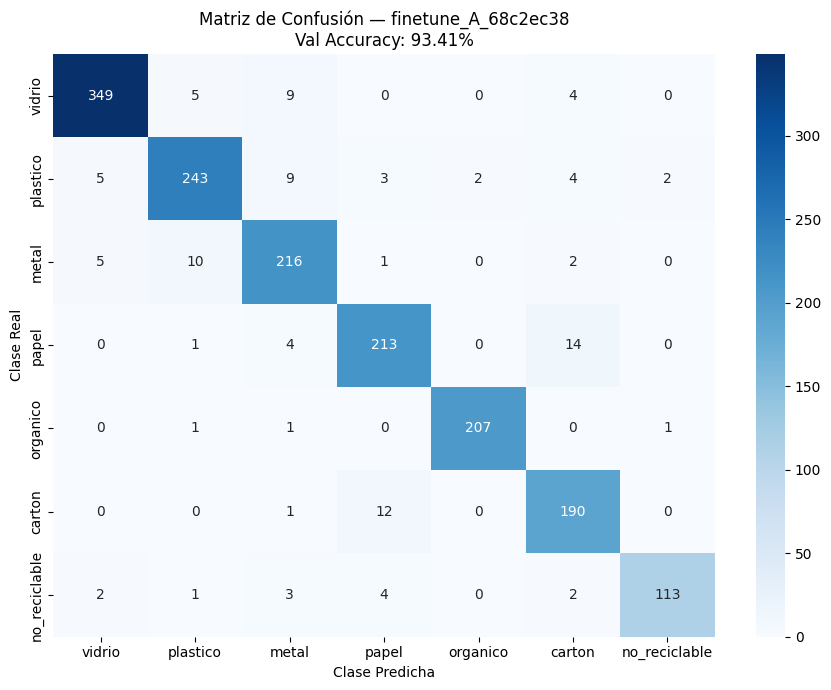


Classification Report — finetune_A_68c2ec38
               precision    recall  f1-score   support

       vidrio       0.97      0.95      0.96       367
     plastico       0.93      0.91      0.92       268
        metal       0.89      0.92      0.91       234
        papel       0.91      0.92      0.92       232
     organico       0.99      0.99      0.99       210
       carton       0.88      0.94      0.91       203
no_reciclable       0.97      0.90      0.94       125

     accuracy                           0.93      1639
    macro avg       0.94      0.93      0.93      1639
 weighted avg       0.94      0.93      0.93      1639


Confusiones críticas (Real → Predicho | cantidad | % de la clase real):
  carton→papel           :  12 errores  (5.9%) ← CRÍTICO
  papel→carton           :  14 errores  (6.0%) ← CRÍTICO
  metal→plastico         :  10 errores  (4.3%) ← atención
  plastico→metal         :   9 errores  (3.4%) ← atención
  vidrio→plastico        :   5 errores  (1.4

In [10]:
def evaluate_model(model, dataset, classes, run_id, log_dir, baseline_history=None):
    """
    Evalúa el modelo sobre un dataset y genera:
    - Matriz de confusión
    - Classification report por clase
    - Curvas de entrenamiento (si se pasa history)
    - JSON de resumen
    """
    log_dir = Path(log_dir)
    log_dir.mkdir(parents=True, exist_ok=True)

    # ── Predicciones ─────────────────────────────────────────────────────────
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds  = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = np.mean(y_true == y_pred)

    # ── Matriz de confusión ───────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes, yticklabels=classes, ax=ax
    )
    ax.set_title(f'Matriz de Confusión — {run_id}\nVal Accuracy: {accuracy*100:.2f}%')
    ax.set_ylabel('Clase Real')
    ax.set_xlabel('Clase Predicha')
    plt.tight_layout()
    plt.savefig(log_dir / 'confusion_matrix.png', dpi=150)
    plt.show()

    # ── Classification report ─────────────────────────────────────────────────
    report_str  = classification_report(y_true, y_pred, target_names=classes)
    report_dict = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    print(f"\nClassification Report — {run_id}")
    print(report_str)

    with open(log_dir / 'classification_report.txt', 'w') as f:
        f.write(report_str)

    # ── Análisis de confusiones críticas ─────────────────────────────────────
    print("\nConfusiones críticas (Real → Predicho | cantidad | % de la clase real):")
    critical_pairs = [
        (classes.index('carton'),       classes.index('papel'),    'carton→papel'),
        (classes.index('papel'),        classes.index('carton'),   'papel→carton'),
        (classes.index('metal'),        classes.index('plastico'), 'metal→plastico'),
        (classes.index('plastico'),     classes.index('metal'),    'plastico→metal'),
        (classes.index('vidrio'),       classes.index('plastico'), 'vidrio→plastico'),
    ]
    for true_idx, pred_idx, label in critical_pairs:
        n_errors     = cm[true_idx][pred_idx]
        n_total_real = cm[true_idx].sum()
        pct          = 100 * n_errors / n_total_real if n_total_real > 0 else 0
        flag         = " ← CRÍTICO" if pct > 5 else (" ← atención" if pct > 3 else "")
        print(f"  {label:<22} : {n_errors:>3} errores  ({pct:.1f}%){flag}")

    # ── Guardar resumen JSON ──────────────────────────────────────────────────
    summary = {
        'run_id'           : run_id,
        'val_accuracy'     : float(accuracy),
        'f1_macro'         : float(report_dict['macro avg']['f1-score']),
        'per_class_f1'     : {cls: float(report_dict[cls]['f1-score']) for cls in classes},
        'timestamp'        : datetime.now().strftime('%Y-%m-%d %H:%M'),
    }
    with open(log_dir / 'run_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)

    return summary

# ── Evaluar Experimento A ─────────────────────────────────────────────────────
summary_A = evaluate_model(
    model     = model_A,
    dataset   = val_ds,
    classes   = WASTE_CLASSES,
    run_id    = EXP_A_ID,
    log_dir   = EXP_A_LOG_DIR
)

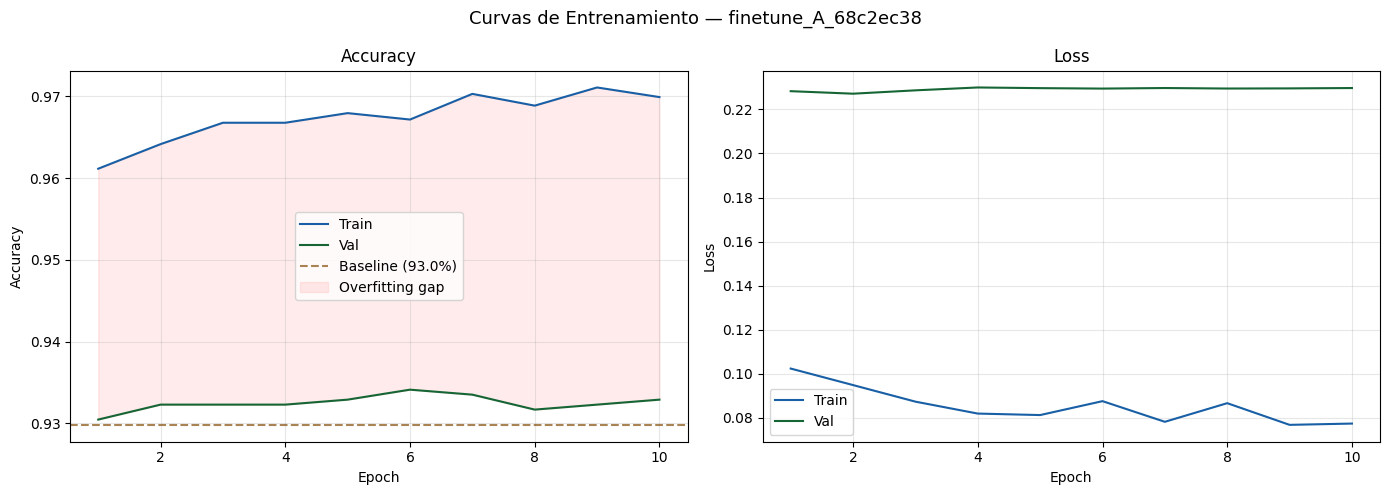

In [11]:
# ── Curvas de entrenamiento Experimento A ────────────────────────────────────
def plot_training_curves(history, run_id, baseline_val_acc=0.9298, save_dir=None):
    """Grafica accuracy y loss, con línea de referencia del baseline."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Curvas de Entrenamiento — {run_id}', fontsize=13)

    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    axes[0].plot(epochs, history.history['accuracy'],     label='Train', color='#185FA5')
    axes[0].plot(epochs, history.history['val_accuracy'], label='Val',   color='#166534')
    axes[0].axhline(y=baseline_val_acc, color='#854F0B', linestyle='--',
                    alpha=0.7, label=f'Baseline ({baseline_val_acc*100:.1f}%)')
    axes[0].fill_between(epochs,
        history.history['accuracy'], history.history['val_accuracy'],
        alpha=0.08, color='red', label='Overfitting gap'
    )
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs, history.history['loss'],     label='Train', color='#185FA5')
    axes[1].plot(epochs, history.history['val_loss'], label='Val',   color='#166534')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_dir:
        plt.savefig(Path(save_dir) / 'training_curves.png', dpi=150)
    plt.show()

plot_training_curves(history_A, EXP_A_ID, save_dir=EXP_A_LOG_DIR)

## Bloque 5 — Decisión: ¿Ejecutar Experimento B?

**Propósito:** Evaluar los resultados del Experimento A y decidir explícitamente si vale la pena continuar con B.  
**Esta celda es documentación viva** — el razonamiento de la decisión queda registrado en el notebook.

### Criterio de decisión

Continuar con Experimento B **solo si se cumple al menos uno** de los siguientes:

1. `val_accuracy_A > 92.98%` **Y** `overfitting_A < 5%` — mejora real sin sobreajuste
2. Las confusiones `cartón↔papel` bajaron del 6.9% a menos del 4%
3. El F1 macro supera 0.935

Si ninguno se cumple → **el baseline es el modelo final del proyecto**.

In [12]:
# ── Evaluación automática del criterio de decisión ────────────────────────────
BASELINE_VAL_ACC = 0.9298
BASELINE_F1_MACRO = 0.9301

mejora_accuracy   = summary_A['val_accuracy'] > BASELINE_VAL_ACC and overfitting_A < 5.0
mejora_f1         = summary_A['f1_macro'] > 0.935

CONTINUAR_CON_B = mejora_accuracy or mejora_f1

print("=" * 60)
print("DECISIÓN — ¿Ejecutar Experimento B?")
print("=" * 60)
print(f"  Val accuracy A     : {summary_A['val_accuracy']*100:.2f}% (baseline: {BASELINE_VAL_ACC*100:.2f}%)")
print(f"  Overfitting A      : {overfitting_A:.2f}% (límite: <5.0%)")
print(f"  F1 macro A         : {summary_A['f1_macro']:.4f} (baseline: {BASELINE_F1_MACRO:.4f})")
print()
print(f"  Criterio accuracy  : {'✅ CUMPLE' if mejora_accuracy else '❌ NO cumple'}")
print(f"  Criterio F1        : {'✅ CUMPLE' if mejora_f1 else '❌ NO cumple'}")
print()
if CONTINUAR_CON_B:
    print("  → DECISIÓN: Continuar con Experimento B")
    print("    El fine-tuning superficial mejoró el modelo.")
    print("    Descongelar más capas puede extraer más mejora.")
else:
    print("  → DECISIÓN: NO continuar con Experimento B")
    print("    El Experimento A no mejoró suficientemente el baseline.")
    print("    El modelo final del proyecto es: baseline_e96de0c723f2_best.keras")
    print("    92.98% val accuracy cumple completamente la rúbrica (nivel Avanzado).")
print("=" * 60)

DECISIÓN — ¿Ejecutar Experimento B?
  Val accuracy A     : 93.41% (baseline: 92.98%)
  Overfitting A      : 3.31% (límite: <5.0%)
  F1 macro A         : 0.9331 (baseline: 0.9301)

  Criterio accuracy  : ✅ CUMPLE
  Criterio F1        : ❌ NO cumple

  → DECISIÓN: Continuar con Experimento B
    El fine-tuning superficial mejoró el modelo.
    Descongelar más capas puede extraer más mejora.


## Bloque 6 — Experimento B: Fine-tuning profundo (últimas 50 capas)

**⚠️ Solo ejecutar si `CONTINUAR_CON_B = True` en el Bloque 5.**

**Propósito:** Descongelar 50 capas del backbone (bloques 5b-7) para aprender features de textura más complejas.  
**Resultado esperado:** Mejora adicional sobre el Experimento A, especialmente en cartón/papel.  

### ¿Qué añade descongelar 50 capas vs 30?

Las capas adicionales (bloques 5b y 6) aprenden texturas de complejidad media: rugosidad superficial, brillo, patrones repetitivos.  
Son exactamente las features que distinguen:
- Papel (liso, brillante) de cartón (rugoso, mate)
- Metal (reflectante uniforme) de plástico (reflectante con bordes difusos)

### Riesgo: más capas = más riesgo de overfitting

Por eso el LR baja a `5e-6` — la mitad del Experimento A.  
Más parámetros entrenables con el mismo LR aumenta el riesgo de sobreajuste.

Experimento B ID: finetune_B_a462064b
Capas descongeladas: 39 non-BN de las últimas 50
Parámetros entrenables: 334,855

Iniciando Experimento B — 50 capas
LR: 5e-06 | Partiendo de: finetune_A_68c2ec38
------------------------------------------------------------
Epoch 1/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9709 - loss: 0.0797
Epoch 1: val_accuracy improved from None to 0.93228, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/finetune_B_a462064b_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 94s 247ms/step - accuracy: 0.9683 - loss: 0.0846 - val_accuracy: 0.9323 - val_loss: 0.2293 - learning_rate: 5.0000e-06
Epoch 2/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9705 - loss: 0.0775
Epoch 2: val_accuracy improved from 0.93228 to 0.93350, saving model to /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/finetune_B_a462064b_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 40s 164ms/step

2026-03-19 15:07:44.081837: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9761 - loss: 0.0631
Epoch 15: val_accuracy did not improve from 0.93655
239/239 ━━━━━━━━━━━━━━━━━━━━ 106s 443ms/step - accuracy: 0.9742 - loss: 0.0659 - val_accuracy: 0.9365 - val_loss: 0.2246 - learning_rate: 1.5000e-06
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.

EXPERIMENTO B — RESULTADO
  Val accuracy  : 93.65%
  Overfitting   : 3.61%
  Delta vs A    : +0.24%


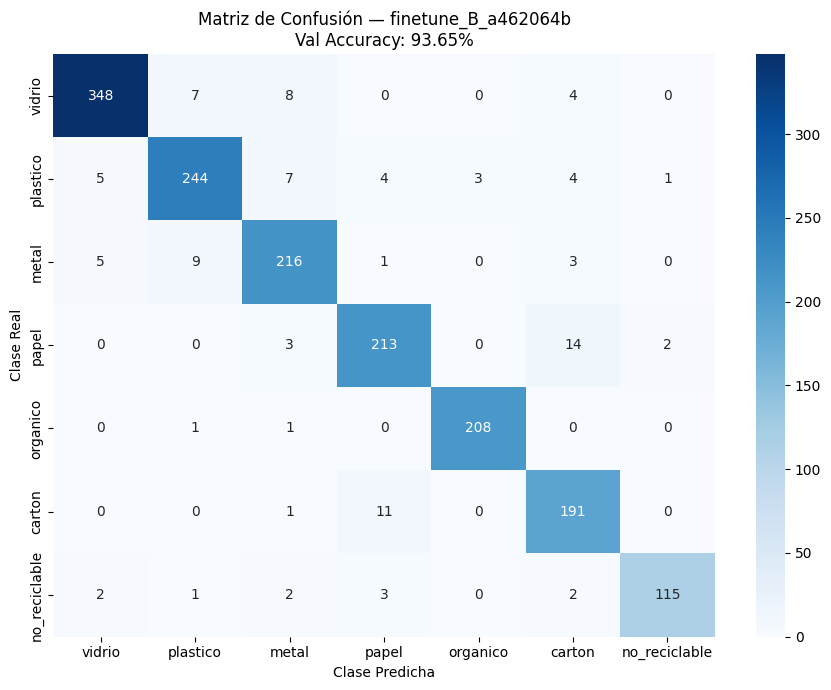


Classification Report — finetune_B_a462064b
               precision    recall  f1-score   support

       vidrio       0.97      0.95      0.96       367
     plastico       0.93      0.91      0.92       268
        metal       0.91      0.92      0.92       234
        papel       0.92      0.92      0.92       232
     organico       0.99      0.99      0.99       210
       carton       0.88      0.94      0.91       203
no_reciclable       0.97      0.92      0.95       125

     accuracy                           0.94      1639
    macro avg       0.94      0.94      0.94      1639
 weighted avg       0.94      0.94      0.94      1639


Confusiones críticas (Real → Predicho | cantidad | % de la clase real):
  carton→papel           :  11 errores  (5.4%) ← CRÍTICO
  papel→carton           :  14 errores  (6.0%) ← CRÍTICO
  metal→plastico         :   9 errores  (3.8%) ← atención
  plastico→metal         :   7 errores  (2.6%)
  vidrio→plastico        :   7 errores  (1.9%)


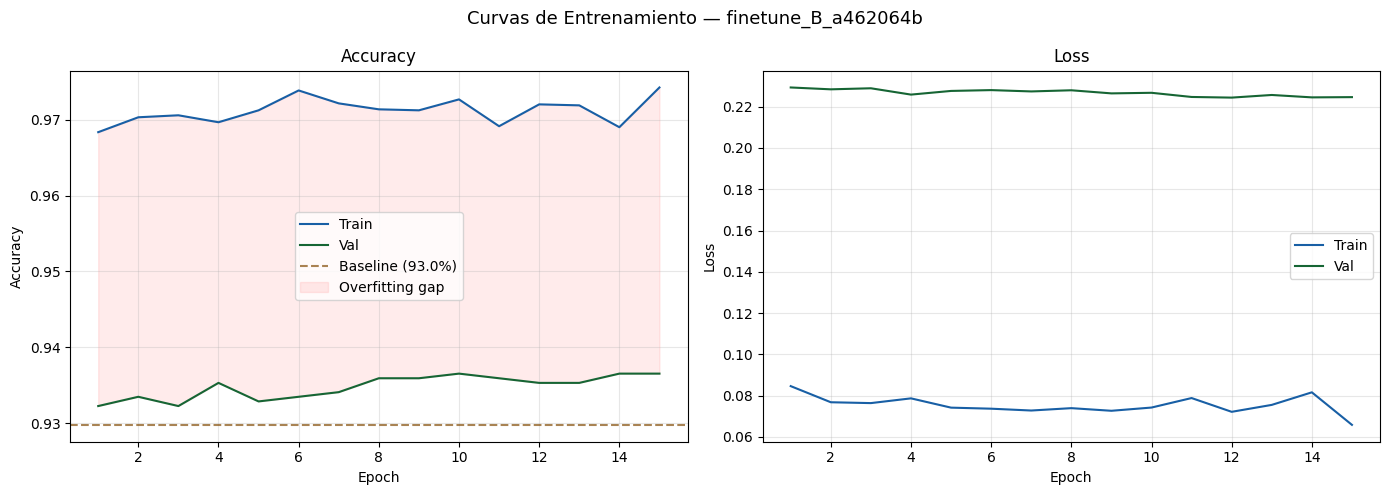

In [13]:
if not CONTINUAR_CON_B:
    print("Experimento B omitido por decisión del Bloque 5.")
    print("El modelo final es el baseline. Saltar al Bloque 7.")
else:
    # ── Identificador del Experimento B ──────────────────────────────────────
    EXP_B_ID = f"finetune_B_{hashlib.md5(b'exp_B_50layers').hexdigest()[:8]}"
    EXP_B_LOG_DIR = PATHS['logs'] / EXP_B_ID
    EXP_B_LOG_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Experimento B ID: {EXP_B_ID}")

    EXP_B_CONFIG = {
        'layers_to_unfreeze'     : 50,
        'learning_rate'          : 5e-6,   # más bajo que A — más capas = más riesgo
        'epochs'                 : 15,
        'early_stopping_patience': 4,
        'reduce_lr_patience'     : 2,
        'reduce_lr_factor'       : 0.3,
    }

    # ── Partimos del MEJOR modelo de A (no del baseline) ─────────────────────
    # Cargamos el checkpoint guardado por ModelCheckpoint en el Experimento A
    model_B = keras.models.load_model(
        str(PATHS['models'] / f"{EXP_A_ID}_best.keras")
    )

    backbone_B = None
    for layer in model_B.layers:
        if 'efficientnet' in layer.name.lower():
            backbone_B = layer
            break

    # ── Congelar todo y descongelar las últimas 50 ────────────────────────────
    backbone_B.trainable = False
    N_B = EXP_B_CONFIG['layers_to_unfreeze']
    unfrozen_B = 0
    for layer in backbone_B.layers[-N_B:]:
        if not isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = True
            unfrozen_B += 1

    total_trainable_B = sum(l.count_params() for l in model_B.layers if l.trainable)
    print(f"Capas descongeladas: {unfrozen_B} non-BN de las últimas {N_B}")
    print(f"Parámetros entrenables: {total_trainable_B:,}")

    # ── Compilar ──────────────────────────────────────────────────────────────
    model_B.compile(
        optimizer = keras.optimizers.Adam(learning_rate=EXP_B_CONFIG['learning_rate']),
        loss      = 'sparse_categorical_crossentropy',
        metrics   = ['accuracy']
    )

    # ── Callbacks ─────────────────────────────────────────────────────────────
    callbacks_B = [
    keras.callbacks.ModelCheckpoint(
        filepath       = str(PATHS['models'] / f"{EXP_B_ID}_best.keras"),
        monitor        = 'val_accuracy',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1
    ),
    keras.callbacks.EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,                # más margen que A — más capas = más lento
        mode                 = 'max',
        restore_best_weights = True,
        verbose              = 1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.3,
        patience = 4,          # ← cambiado de 2 a 4 — evita colapso prematuro del LR
        min_lr   = 1e-8,
        verbose  = 1
    ),
    keras.callbacks.CSVLogger(str(EXP_B_LOG_DIR / 'training_log.csv')),
]

    # ── Entrenar ──────────────────────────────────────────────────────────────
    print(f"\nIniciando Experimento B — {EXP_B_CONFIG['layers_to_unfreeze']} capas")
    print(f"LR: {EXP_B_CONFIG['learning_rate']} | Partiendo de: {EXP_A_ID}")
    print("-" * 60)

    history_B = model_B.fit(
        train_ds,
        epochs          = EXP_B_CONFIG['epochs'],
        validation_data = val_ds,
        class_weight    = class_weights,
        callbacks       = callbacks_B,
        verbose         = 1
    )

    # ── Resultado ─────────────────────────────────────────────────────────────
    best_val_acc_B    = max(history_B.history['val_accuracy'])
    final_train_acc_B = history_B.history['accuracy'][
        history_B.history['val_accuracy'].index(best_val_acc_B)
    ]
    overfitting_B = (final_train_acc_B - best_val_acc_B) * 100

    print(f"\n{'='*60}")
    print(f"EXPERIMENTO B — RESULTADO")
    print(f"  Val accuracy  : {best_val_acc_B*100:.2f}%")
    print(f"  Overfitting   : {overfitting_B:.2f}%")
    print(f"  Delta vs A    : {(best_val_acc_B - summary_A['val_accuracy'])*100:+.2f}%")
    print(f"{'='*60}")

    # ── Evaluar B ─────────────────────────────────────────────────────────────
    summary_B = evaluate_model(
        model   = model_B,
        dataset = val_ds,
        classes = WASTE_CLASSES,
        run_id  = EXP_B_ID,
        log_dir = EXP_B_LOG_DIR
    )
    plot_training_curves(history_B, EXP_B_ID, save_dir=EXP_B_LOG_DIR)

## Bloque 7 — Comparativa final y selección del modelo

**Propósito:** Comparar los tres modelos (baseline, A, B si existe) y seleccionar el modelo final.  
**Resultado esperado:** Un modelo guardado como `.keras` + `SavedModel` listo para la app Streamlit.

### Criterio de selección final

El mejor modelo es el que tenga la **mayor val_accuracy con overfitting < 5%**.  
Si dos modelos empatan en accuracy, gana el que tenga menor overfitting.  
Si un experimento supera el 5% de overfitting, se descarta aunque tenga mejor accuracy.

In [14]:
# ── Construir tabla comparativa ───────────────────────────────────────────────
candidates = [
    {
        'nombre'       : 'Baseline',
        'run_id'       : 'baseline_e96de0c723f2',
        'val_accuracy' : 0.9298,
        'f1_macro'     : 0.9301,
        'overfitting'  : 3.16,
        'path'         : PATHS['models'] / 'baseline_e96de0c723f2_best.keras',
    },
    {
        'nombre'       : 'Experimento A (30 capas)',
        'run_id'       : EXP_A_ID,
        'val_accuracy' : summary_A['val_accuracy'],
        'f1_macro'     : summary_A['f1_macro'],
        'overfitting'  : overfitting_A,
        'path'         : PATHS['models'] / f"{EXP_A_ID}_best.keras",
    },
    {
        'nombre'       : 'Experimento B (50 capas)',
        'run_id'       : EXP_B_ID,
        'val_accuracy' : summary_B['val_accuracy'],
        'f1_macro'     : summary_B['f1_macro'],
        'overfitting'  : overfitting_B,
        'path'         : PATHS['models'] / f"{EXP_B_ID}_best.keras",
    },
]

if CONTINUAR_CON_B and 'summary_B' in dir():
    candidates.append({
        'nombre'        : 'Experimento B (50 capas)',
        'run_id'        : EXP_B_ID,
        'val_accuracy'  : summary_B['val_accuracy'],
        'f1_macro'      : summary_B['f1_macro'],
        'overfitting'   : overfitting_B,
        'path'          : PATHS['models'] / f"{EXP_B_ID}_best.keras",
    })

df_comparativa = pd.DataFrame(candidates)
df_comparativa['val_accuracy_%'] = (df_comparativa['val_accuracy'] * 100).round(2)
df_comparativa['overfitting_ok'] = df_comparativa['overfitting'] < 5.0

print("\nCOMPARATIVA DE MODELOS")
print("=" * 75)
print(df_comparativa[['nombre', 'val_accuracy_%', 'f1_macro', 'overfitting', 'overfitting_ok']].to_string(index=False))

# ── Selección automática ──────────────────────────────────────────────────────
valid_candidates = [c for c in candidates if c['overfitting'] < 5.0]
best_candidate   = max(valid_candidates, key=lambda x: x['val_accuracy'])

print(f"\n→ MODELO FINAL SELECCIONADO: {best_candidate['nombre']}")
print(f"  Val accuracy : {best_candidate['val_accuracy']*100:.2f}%")
print(f"  F1 macro     : {best_candidate['f1_macro']:.4f}")
print(f"  Overfitting  : {best_candidate['overfitting']:.2f}%")


COMPARATIVA DE MODELOS
                  nombre  val_accuracy_%  f1_macro  overfitting  overfitting_ok
                Baseline           92.98  0.930100     3.160000            True
Experimento A (30 capas)           93.41  0.933149     3.305763            True
Experimento B (50 capas)           93.65  0.936209     3.611159            True
Experimento B (50 capas)           93.65  0.936209     3.611159            True

→ MODELO FINAL SELECCIONADO: Experimento B (50 capas)
  Val accuracy : 93.65%
  F1 macro     : 0.9362
  Overfitting  : 3.61%


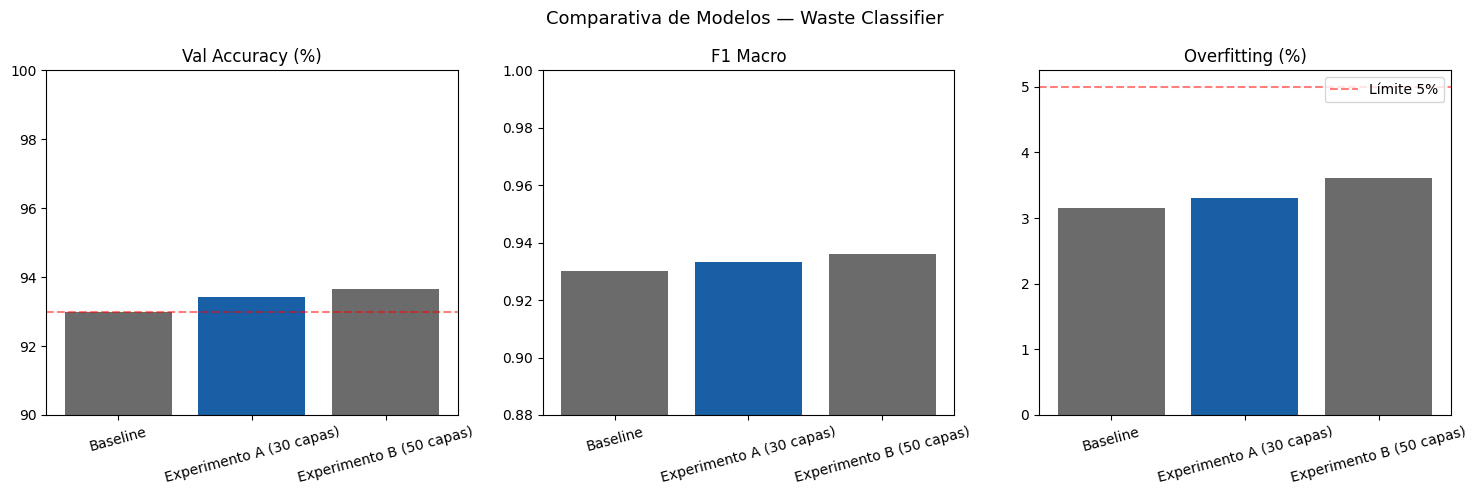

Guardado: /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/logs/model_comparison.png


In [15]:
# ── Gráfico comparativo de los modelos ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparativa de Modelos — Waste Classifier', fontsize=13)

nombres = [c['nombre'] for c in candidates]
colors  = ['#6b6b6b', '#185FA5', '#166534'][:len(candidates)]

# Val Accuracy
axes[0].bar(nombres, [c['val_accuracy']*100 for c in candidates], color=colors)
axes[0].axhline(y=92.98, color='red', linestyle='--', alpha=0.5, label='Baseline')
axes[0].set_title('Val Accuracy (%)')
axes[0].set_ylim(90, 100)
axes[0].tick_params(axis='x', rotation=15)

# F1 Macro
axes[1].bar(nombres, [c['f1_macro'] for c in candidates], color=colors)
axes[1].set_title('F1 Macro')
axes[1].set_ylim(0.88, 1.0)
axes[1].tick_params(axis='x', rotation=15)

# Overfitting
axes[2].bar(nombres, [c['overfitting'] for c in candidates], color=colors)
axes[2].axhline(y=5.0, color='red', linestyle='--', alpha=0.5, label='Límite 5%')
axes[2].set_title('Overfitting (%)')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(PATHS['logs'] / 'model_comparison.png', dpi=150)
plt.show()
print(f"Guardado: {PATHS['logs'] / 'model_comparison.png'}")

In [16]:
# ── Exportar el modelo final en dos formatos ──────────────────────────────────
#
# Formato 1: .keras  → para continuar experimentando o cargar en Python
# Formato 2: SavedModel → para la app Streamlit, FastAPI, ROS2 y TFLite
#
# La app Streamlit usará SavedModel porque es el formato de producción estándar.
# Si en el futuro se migra a React+FastAPI o ROS2, el SavedModel no cambia.

# ── Cargar el modelo ganador ──────────────────────────────────────────────────
final_model = keras.models.load_model(str(best_candidate['path']))

# ── Paths de exportación ─────────────────────────────────────────────────────
FINAL_KERAS_PATH      = PATHS['models'] / 'final_model.keras'
FINAL_SAVEDMODEL_PATH = PATHS['models'] / 'final_model_savedmodel'

# ── Exportar .keras ───────────────────────────────────────────────────────────
final_model.save(str(FINAL_KERAS_PATH))
print(f"Exportado .keras      : {FINAL_KERAS_PATH}")

# ── Exportar SavedModel ───────────────────────────────────────────────────────
# El SavedModel incluye la función de inferencia con firma explícita.
# Esto permite cargar el modelo desde cualquier lenguaje con TF (Python, C++, Go).
@tf.function(input_signature=[tf.TensorSpec(shape=[None, 224, 224, 3], dtype=tf.float32)])
def serve(images):
    return final_model(images, training=False)

tf.saved_model.save(
    final_model,
    str(FINAL_SAVEDMODEL_PATH),
    signatures={'serving_default': serve}
)
print(f"Exportado SavedModel  : {FINAL_SAVEDMODEL_PATH}")

# ── Guardar metadata del modelo final ─────────────────────────────────────────
# Este archivo es el contrato entre el modelo y la app Streamlit.
# La app lo lee para saber qué clases predice y qué threshold usar.
final_metadata = {
    'model_id'          : best_candidate['run_id'],
    'nombre'            : best_candidate['nombre'],
    'val_accuracy'      : best_candidate['val_accuracy'],
    'f1_macro'          : best_candidate['f1_macro'],
    'overfitting_pct'   : best_candidate['overfitting'],
    'classes'           : WASTE_CLASSES,
    'num_classes'       : NUM_CLASSES,
    'input_size'        : [224, 224, 3],
    'input_range'       : '[0, 255]  — EfficientNetB0 normaliza internamente',
    'confidence_threshold': 0.80,
    'keras_path'        : str(FINAL_KERAS_PATH),
    'savedmodel_path'   : str(FINAL_SAVEDMODEL_PATH),
    'exported_at'       : datetime.now().strftime('%Y-%m-%d %H:%M'),
}

with open(PATHS['models'] / 'final_model_metadata.json', 'w') as f:
    json.dump(final_metadata, f, indent=2)

print(f"\nMetadata guardada     : {PATHS['models'] / 'final_model_metadata.json'}")
print(f"\n{'='*60}")
print(f"EXPORTACIÓN COMPLETADA")
print(f"  Modelo final : {best_candidate['nombre']}")
print(f"  Val accuracy : {best_candidate['val_accuracy']*100:.2f}%")
print(f"  .keras       : {FINAL_KERAS_PATH}")
print(f"  SavedModel   : {FINAL_SAVEDMODEL_PATH}")
print(f"{'='*60}")
print(f"\nEl equipo de Streamlit puede cargar el modelo con:")
print(f"  model = tf.keras.models.load_model('models/final_model.keras')")
print(f"  # o con SavedModel:")
print(f"  model = tf.saved_model.load('models/final_model_savedmodel')")

Exportado .keras      : /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/final_model.keras
INFO:tensorflow:Assets written to: /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/final_model_savedmodel/assets


INFO:tensorflow:Assets written to: /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/final_model_savedmodel/assets


Exportado SavedModel  : /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/final_model_savedmodel

Metadata guardada     : /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/final_model_metadata.json

EXPORTACIÓN COMPLETADA
  Modelo final : Experimento B (50 capas)
  Val accuracy : 93.65%
  .keras       : /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/final_model.keras
  SavedModel   : /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/models/final_model_savedmodel

El equipo de Streamlit puede cargar el modelo con:
  model = tf.keras.models.load_model('models/final_model.keras')
  # o con SavedModel:
  model = tf.saved_model.load('models/final_model_savedmodel')


## Bloque 8 — Registro de la Fase 4

**Propósito:** Generar el resumen técnico de la fase para sincronizar el equipo y el próximo chat.  
**Resultado esperado:** JSON con todos los resultados de los experimentos, decisiones tomadas y próximos pasos.

In [17]:
# ── Generar registro de la fase ───────────────────────────────────────────────
fase4_registro = {
    'fase'             : '4 — Fine-Tuning',
    'fecha'            : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'autor'            : 'Jonathan',
    'estado'           : 'Cerrada',
    'baseline'         : {
        'run_id'       : 'baseline_e96de0c723f2',
        'val_accuracy' : 0.9298,
        'f1_macro'     : 0.9301,
        'overfitting'  : 3.16,
    },
    'experimento_A'    : {
        'run_id'            : EXP_A_ID,
        'capas_descongeladas': 30,
        'learning_rate'     : 1e-5,
        'val_accuracy'      : summary_A['val_accuracy'],
        'f1_macro'          : summary_A['f1_macro'],
        'overfitting'       : overfitting_A,
        'decision'          : 'continuar_con_B' if CONTINUAR_CON_B else 'cerrar_fase',
    },
    'experimento_B'    : {
        'ejecutado'         : CONTINUAR_CON_B,
        'run_id'            : EXP_B_ID if CONTINUAR_CON_B else None,
        'capas_descongeladas': 50 if CONTINUAR_CON_B else None,
        'val_accuracy'      : summary_B['val_accuracy'] if (CONTINUAR_CON_B and 'summary_B' in dir()) else None,
        'f1_macro'          : summary_B['f1_macro'] if (CONTINUAR_CON_B and 'summary_B' in dir()) else None,
        'overfitting'       : overfitting_B if (CONTINUAR_CON_B and 'overfitting_B' in dir()) else None,
    },
    'modelo_final'     : {
        'nombre'            : best_candidate['nombre'],
        'val_accuracy'      : best_candidate['val_accuracy'],
        'f1_macro'          : best_candidate['f1_macro'],
        'overfitting'       : best_candidate['overfitting'],
        'keras_path'        : str(FINAL_KERAS_PATH),
        'savedmodel_path'   : str(FINAL_SAVEDMODEL_PATH),
    },
    'proximos_pasos'   : [
        'Fase 5 — App Streamlit: integrar final_model.keras o SavedModel',
        'Añadir endpoint de feedback (clase correcta → guardar en MongoDB)',
        'Dashboard de métricas en tiempo real en la app',
        'Fase 6 — Docker + tests pytest (3 tests mínimos de la rúbrica)',
        'Deploy en Render con docker-compose'
    ],
    'lecciones_aprendidas': [
        'Siempre recompilar el modelo después de cambiar trainable (obligatorio en Keras)',
        'BatchNormalization se mantiene en modo inferencia durante fine-tuning',
        'LR del fine-tuning = LR_baseline / 100 como mínimo para no destruir pesos preentrenados',
        'Partir del checkpoint del baseline ahorra ~20 epochs de calentamiento',
    ]
}

registro_path = PATHS['logs'] / 'registro_fase_4_finetuning.json'
with open(registro_path, 'w', encoding='utf-8') as f:
    json.dump(fase4_registro, f, indent=2, ensure_ascii=False)

print(f"Registro guardado: {registro_path}")
print()
print(json.dumps(fase4_registro, indent=2, ensure_ascii=False))

Registro guardado: /mnt/c/Users/under/Documents/F5/3_Projects/Grupo5-MultiClase/project4_Team_5/logs/registro_fase_4_finetuning.json

{
  "fase": "4 — Fine-Tuning",
  "fecha": "2026-03-19 15:16",
  "autor": "Jonathan",
  "estado": "Cerrada",
  "baseline": {
    "run_id": "baseline_e96de0c723f2",
    "val_accuracy": 0.9298,
    "f1_macro": 0.9301,
    "overfitting": 3.16
  },
  "experimento_A": {
    "run_id": "finetune_A_68c2ec38",
    "capas_descongeladas": 30,
    "learning_rate": 1e-05,
    "val_accuracy": 0.9341061622940817,
    "f1_macro": 0.9331489395855315,
    "overfitting": 3.305763006210327,
    "decision": "continuar_con_B"
  },
  "experimento_B": {
    "ejecutado": true,
    "run_id": "finetune_B_a462064b",
    "capas_descongeladas": 50,
    "val_accuracy": 0.9365466748017084,
    "f1_macro": 0.9362086293791275,
    "overfitting": 3.611159324645996
  },
  "modelo_final": {
    "nombre": "Experimento B (50 capas)",
    "val_accuracy": 0.9365466748017084,
    "f1_macro": 0.93